In [1]:
!pip install matplotlib

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import roc_auc_score, roc_curve
import json, random, os
import torch

In [2]:
import sys
import os

sys.path.append(os.path.abspath(".."))

In [3]:
from model import load_sentence_encoder, load_model, generate_response, generate_batch
from scoring import clean_response, compute_stability, is_uncertainty_response, plateau_stop, responses_are_substantive
from data import load_triviaqa, load_mmlu, load_webquestions
from evaluate import evaluate, run_full_evaluation, print_comparison_table
from calibration import compute_qhat, check_coverage, run_calibration
from sampler import adaptive_sample, check_coverage, build_prediction_set
from helpers import _assign_split, _print_split_counts, filter_split, clear_embed_cache, embed_cached
from scoring import clean_response, compute_stability, plateau_stop, is_uncertainty_response, responses_are_substantive, token_f1
from config import QASample, SamplerConfig, UNCERTAINTY_TOKENS, COVERAGE_SIM_THRESHOLD, MMLU_SUBJECTS

c:\Users\yash.paudel\AppData\Local\anaconda3\envs\sashuv-env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
assert DEVICE == "cuda", "Switch to GPU runtime: Runtime > Change runtime type > T4 GPU"

Device: cuda


In [5]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [6]:
triviaqa_samples   = load_triviaqa(SEED, n_total=3000)
webq_samples       = load_webquestions(SEED)
mmlu_samples       = load_mmlu(SEED)

DATASETS = {
    "triviaqa": triviaqa_samples,
    "webq":     webq_samples,
    "mmlu":     mmlu_samples,
}

# Quick sanity check
for name, samples in DATASETS.items():
    cal  = len(filter_split(samples, "calibration"))
    val  = len(filter_split(samples, "validation"))
    test = len(filter_split(samples, "test"))
    print(f"{name}: cal={cal}, val={val}, test={test}")

TriviaQA loaded: 3000 samples
  calibration: 1500
  validation: 750
  test: 750
WebQuestions loaded: 3778 samples
  calibration: 1889
  validation: 945
  test: 944
MMLU loaded: 2314 samples across 5 subjects
  calibration: 1157
  validation: 579
  test: 578
triviaqa: cal=1500, val=750, test=750
webq: cal=1889, val=945, test=944
mmlu: cal=1157, val=579, test=578


In [7]:
DATASET      = "triviaqa"
N_QUESTIONS  = 500        # number of test questions
RESULTS_PATH = "./correctness_experiment.json"
FIGURES_PATH = "./results/"

os.makedirs(FIGURES_PATH, exist_ok=True)

In [8]:
model, tokenizer = load_model()

Loading mistralai/Mistral-7B-Instruct-v0.3 ...


`torch_dtype` is deprecated! Use `dtype` instead!
W0406 11:49:17.640000 21616 site-packages\torch\utils\flop_counter.py:29] triton not found; flop counting will not work for triton kernels
Loading weights:   1%|          | 2/291 [00:00<00:57,  5.01it/s]c:\Users\yash.paudel\AppData\Local\anaconda3\envs\sashuv-env\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 291/291 [00:07<00:00, 40.39it/s]


Model loaded.
GPU memory used: 4.1 GB


In [9]:
DEFAULT_CONFIG = SamplerConfig()

In [10]:
def get_greedy_answer(model, tokenizer, question: str) -> str:
    return generate_response(model, tokenizer, question, temperature=0.1)
 

In [11]:
def run_correctness_experiment(
    model,
    tokenizer,
    dataset_name: str  = DATASET,
    n_questions:  int  = N_QUESTIONS,
    save_path:    str  = RESULTS_PATH,
) -> list:
    """
    For each test question:
      - Run adaptive_sample → N score, abstain flag, cleaned responses
      - Run greedy decode → single best answer
      - Check greedy correctness against gold answers
      - Save everything
 
    Returns list of per-question result dicts.
    """
    test_samples = filter_split(DATASETS[dataset_name], "test")
    if len(test_samples) > n_questions:
        test_samples = random.sample(test_samples, n_questions)
 
    print(f"Running correctness experiment: {dataset_name}, n={len(test_samples)}")
    print(f"Saving to: {save_path}\n")
 
    records = []
 
    for i, sample in enumerate(test_samples):
        clear_embed_cache()
 
        # Step 1: adaptive sample → N score
        result = adaptive_sample(model, tokenizer, sample.question, config=DEFAULT_CONFIG)
 
        # Step 2: greedy answer → correctness
        greedy_raw = get_greedy_answer(model, tokenizer, sample.question)
        greedy_cleaned = clean_response(greedy_raw)
        greedy_correct = check_coverage([greedy_cleaned], sample.gold_answers)
 
        record = {
            "question":      sample.question,
            "gold_answers":  sample.gold_answers,
            "n_score":       result["n_score"],        # None if abstained
            "stability":     result["stability"],
            "abstained":     result["abstain"],
            "reason":        result.get("reason", ""),
            "n_batches":     result["n_batches"],
            "n_samples":     result["n_samples"],
            "responses":     list(set(result["cleaned"]))[:6],
            "greedy_answer": greedy_cleaned,
            "greedy_correct":greedy_correct,
            "history":       result["history"],
        }
        records.append(record)
 
        # Progress
        if (i + 1) % 25 == 0:
            n_done      = i + 1
            n_abstained = sum(1 for r in records if r["abstained"])
            n_correct   = sum(1 for r in records if r["greedy_correct"])
            print(f"  [{n_done:4d}/{len(test_samples)}] "
                  f"greedy_acc={n_correct/n_done*100:.1f}%  "
                  f"abstain_rate={n_abstained/n_done*100:.1f}%")
 
        # Checkpoint every 50
        if (i + 1) % 50 == 0:
            with open(save_path, "w") as f:
                json.dump(records, f, indent=2)
 
    # Final save
    with open(save_path, "w") as f:
        json.dump(records, f, indent=2)
    print(f"\nSaved {len(records)} records to {save_path}")
 
    return records

In [12]:
records = run_correctness_experiment(model, tokenizer)

Running correctness experiment: triviaqa, n=500
Saving to: ./correctness_experiment.json



c:\Users\yash.paudel\AppData\Local\anaconda3\envs\sashuv-env\Lib\site-packages\bitsandbytes\backends\cuda\ops.py:468: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


Loading sentence encoder...


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 7357.05it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoder loaded. Embedding dim: 384
  [  25/500] greedy_acc=76.0%  abstain_rate=8.0%
  [  50/500] greedy_acc=64.0%  abstain_rate=18.0%
  [  75/500] greedy_acc=60.0%  abstain_rate=21.3%
  [ 100/500] greedy_acc=60.0%  abstain_rate=25.0%
  [ 125/500] greedy_acc=60.8%  abstain_rate=25.6%
  [ 150/500] greedy_acc=61.3%  abstain_rate=24.7%
  [ 175/500] greedy_acc=62.3%  abstain_rate=24.0%
  [ 200/500] greedy_acc=62.5%  abstain_rate=22.5%
  [ 225/500] greedy_acc=60.4%  abstain_rate=22.2%
  [ 250/500] greedy_acc=60.8%  abstain_rate=22.0%
  [ 275/500] greedy_acc=61.5%  abstain_rate=22.2%
  [ 300/500] greedy_acc=62.3%  abstain_rate=22.7%
  [ 325/500] greedy_acc=61.8%  abstain_rate=22.8%
  [ 350/500] greedy_acc=62.9%  abstain_rate=22.3%
  [ 375/500] greedy_acc=63.5%  abstain_rate=22.1%
  [ 400/500] greedy_acc=63.2%  abstain_rate=21.8%
  [ 425/500] greedy_acc=64.0%  abstain_rate=21.6%
  [ 450/500] greedy_acc=64.0%  abstain_rate=21.3%
  [ 475/500] greedy_acc=64.4%  abstain_rate=21.3%
  [ 500/500] gre

In [13]:
def compute_metrics(records: list) -> dict:
    """
    Compute AUROC, abstention precision, and binned accuracy from records.
    Separates abstained vs non-abstained questions.
    """
 
    # Split into abstained and scored
    abstained = [r for r in records if r["abstained"]]
    scored    = [r for r in records if not r["abstained"]
                 and r["n_score"] is not None]
 
    # --- AUROC ---
    # Task: predict whether greedy answer is INCORRECT from N score
    # Higher N score should predict incorrectness
    n_scores = [r["n_score"] for r in scored]
    correct  = [1 if r["greedy_correct"] else 0 for r in scored]
    incorrect = [1 - c for c in correct]
 
    auroc = roc_auc_score(incorrect, n_scores) if len(set(incorrect)) > 1 else 0.5
    fpr, tpr, thresholds = roc_curve(incorrect, n_scores)
 
    # --- Abstention precision ---
    # Among abstained questions, what fraction would model get wrong?
    abstain_correct   = sum(1 for r in abstained if r["greedy_correct"])
    abstain_incorrect = len(abstained) - abstain_correct
    abstain_precision = abstain_incorrect / len(abstained) if abstained else 0
 
    # Among answered questions, what fraction correct?
    answered_correct = sum(1 for r in scored if r["greedy_correct"])
    answered_acc     = answered_correct / len(scored) if scored else 0
 
    # --- Binned accuracy (calibration curve) ---
    bins       = np.arange(0, 1.1, 0.1)
    bin_acc    = []
    bin_counts = []
    bin_centers = []
 
    for lo, hi in zip(bins[:-1], bins[1:]):
        in_bin = [r for r in scored
                  if r["n_score"] is not None and lo <= r["n_score"] < hi]
        if in_bin:
            acc = sum(1 for r in in_bin if r["greedy_correct"]) / len(in_bin)
            bin_acc.append(acc)
            bin_counts.append(len(in_bin))
            bin_centers.append((lo + hi) / 2)
        else:
            bin_acc.append(None)
            bin_counts.append(0)
            bin_centers.append((lo + hi) / 2)
 
    # --- N score by correctness ---
    correct_scores   = [r["n_score"] for r in scored if r["greedy_correct"]
                        and r["n_score"] is not None]
    incorrect_scores = [r["n_score"] for r in scored if not r["greedy_correct"]
                        and r["n_score"] is not None]
 
    print(f"\n{'='*55}")
    print(f"CORRECTNESS PREDICTION METRICS")
    print(f"{'='*55}")
    print(f"\n  Total questions     : {len(records)}")
    print(f"  Abstained           : {len(abstained)} "
          f"({len(abstained)/len(records)*100:.1f}%)")
    print(f"  Scored (non-abstain): {len(scored)}")
    print(f"\n  Overall greedy acc  : "
          f"{sum(r['greedy_correct'] for r in records)/len(records)*100:.1f}%")
    print(f"  Answered greedy acc : {answered_acc*100:.1f}%")
    print(f"\n  AUROC               : {auroc:.3f}")
    print(f"  (0.5=random, 1.0=perfect — N score predicts incorrectness)")
    print(f"\n  Abstention precision: {abstain_precision*100:.1f}%")
    print(f"  (% of abstentions where greedy answer is WRONG)")
    print(f"\n  Correct   questions — mean N score: "
          f"{np.mean(correct_scores):.3f} ± {np.std(correct_scores):.3f}")
    print(f"  Incorrect questions — mean N score: "
          f"{np.mean(incorrect_scores):.3f} ± {np.std(incorrect_scores):.3f}")
    print(f"  Separation          : "
          f"{np.mean(incorrect_scores) - np.mean(correct_scores):+.3f}")
 
    return {
        "auroc":              auroc,
        "fpr":                fpr.tolist(),
        "tpr":                tpr.tolist(),
        "abstain_precision":  abstain_precision,
        "answered_acc":       answered_acc,
        "bin_centers":        bin_centers,
        "bin_acc":            bin_acc,
        "bin_counts":         bin_counts,
        "correct_scores":     correct_scores,
        "incorrect_scores":   incorrect_scores,
        "n_abstained":        len(abstained),
        "n_scored":           len(scored),
        "n_total":            len(records),
    }

In [14]:
metrics = compute_metrics(records)


CORRECTNESS PREDICTION METRICS

  Total questions     : 500
  Abstained           : 107 (21.4%)
  Scored (non-abstain): 393

  Overall greedy acc  : 65.2%
  Answered greedy acc : 76.1%

  AUROC               : 0.652
  (0.5=random, 1.0=perfect — N score predicts incorrectness)

  Abstention precision: 74.8%
  (% of abstentions where greedy answer is WRONG)

  Correct   questions — mean N score: 0.029 ± 0.062
  Incorrect questions — mean N score: 0.081 ± 0.098
  Separation          : +0.052


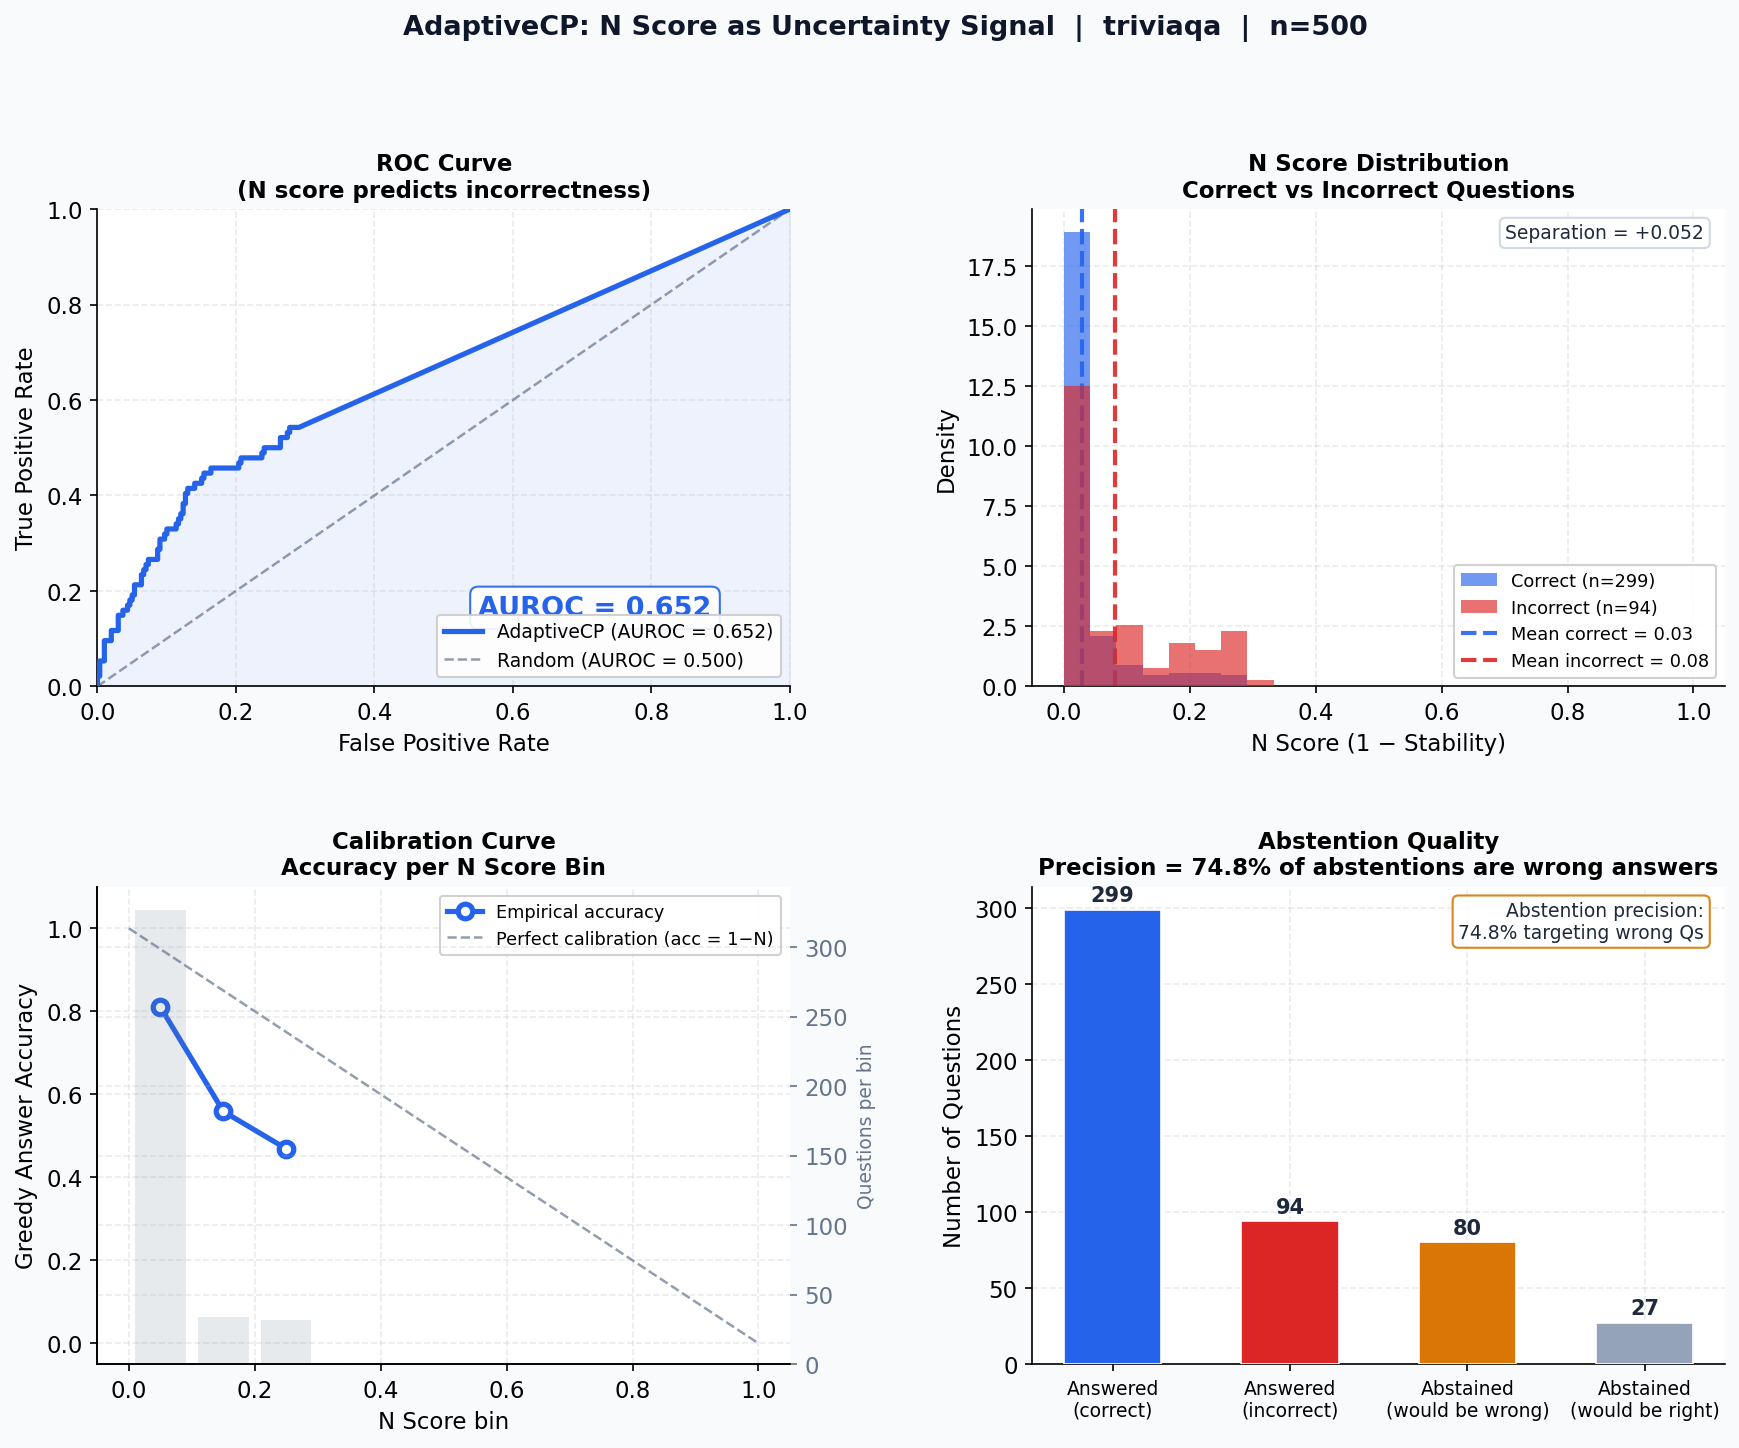

Saved: ./results/correctness_experiment.png


In [15]:
def plot_correctness_experiment(metrics: dict, save_dir: str = FIGURES_PATH):
 
    plt.rcParams.update({
        "font.family":       "DejaVu Sans",
        "font.size":         11,
        "axes.spines.top":   False,
        "axes.spines.right": False,
        "axes.grid":         True,
        "grid.alpha":        0.25,
        "grid.linestyle":    "--",
        "figure.dpi":        150,
    })
 
    fig = plt.figure(figsize=(14, 10))
    fig.patch.set_facecolor("#F8FAFC")
    gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.42, wspace=0.35)
 
    CORRECT_COLOR   = "#2563EB"   # blue
    INCORRECT_COLOR = "#DC2626"   # red
    ABSTAIN_COLOR   = "#D97706"   # amber
    NEUTRAL_COLOR   = "#64748B"   # slate
 
    # ── Panel 1: ROC Curve ────────────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, 0])
 
    ax1.plot(metrics["fpr"], metrics["tpr"],
             color=CORRECT_COLOR, linewidth=2.5, zorder=3,
             label=f"AdaptiveCP (AUROC = {metrics['auroc']:.3f})")
    ax1.plot([0, 1], [0, 1],
             color=NEUTRAL_COLOR, linewidth=1.2,
             linestyle="--", alpha=0.7, label="Random (AUROC = 0.500)")
 
    ax1.fill_between(metrics["fpr"], metrics["tpr"],
                     alpha=0.08, color=CORRECT_COLOR)
 
    ax1.set_xlabel("False Positive Rate", fontsize=11)
    ax1.set_ylabel("True Positive Rate", fontsize=11)
    ax1.set_title("ROC Curve\n(N score predicts incorrectness)",
                  fontsize=11, fontweight="bold")
    ax1.legend(fontsize=9, loc="lower right", framealpha=0.9)
    ax1.set_xlim(0, 1)
    ax1.set_ylim(0, 1)
 
    # Annotate AUROC
    ax1.text(0.55, 0.15,
             f"AUROC = {metrics['auroc']:.3f}",
             fontsize=13, fontweight="bold", color=CORRECT_COLOR,
             transform=ax1.transAxes,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                       edgecolor=CORRECT_COLOR, alpha=0.9))
 
    # ── Panel 2: N score distributions ───────────────────────────────────
    ax2 = fig.add_subplot(gs[0, 1])
 
    bins = np.linspace(0, 1, 25)
 
    ax2.hist(metrics["correct_scores"], bins=bins,
             alpha=0.65, color=CORRECT_COLOR,
             label=f"Correct (n={len(metrics['correct_scores'])})",
             density=True, zorder=3)
    ax2.hist(metrics["incorrect_scores"], bins=bins,
             alpha=0.65, color=INCORRECT_COLOR,
             label=f"Incorrect (n={len(metrics['incorrect_scores'])})",
             density=True, zorder=3)
 
    # Mean lines
    ax2.axvline(np.mean(metrics["correct_scores"]),
                color=CORRECT_COLOR, linewidth=2,
                linestyle="--", alpha=0.9,
                label=f"Mean correct = {np.mean(metrics['correct_scores']):.2f}")
    ax2.axvline(np.mean(metrics["incorrect_scores"]),
                color=INCORRECT_COLOR, linewidth=2,
                linestyle="--", alpha=0.9,
                label=f"Mean incorrect = {np.mean(metrics['incorrect_scores']):.2f}")
 
    ax2.set_xlabel("N Score (1 − Stability)", fontsize=11)
    ax2.set_ylabel("Density", fontsize=11)
    ax2.set_title("N Score Distribution\nCorrect vs Incorrect Questions",
                  fontsize=11, fontweight="bold")
    ax2.legend(fontsize=8.5, framealpha=0.9)
 
    sep = np.mean(metrics["incorrect_scores"]) - np.mean(metrics["correct_scores"])
    ax2.text(0.97, 0.97,
             f"Separation = {sep:+.3f}",
             transform=ax2.transAxes, ha="right", va="top",
             fontsize=9, color="#1E293B",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                       edgecolor="#CBD5E1", alpha=0.9))
 
    # ── Panel 3: Calibration curve ────────────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 0])
 
    valid = [(c, a, n) for c, a, n in
             zip(metrics["bin_centers"], metrics["bin_acc"],
                 metrics["bin_counts"])
             if a is not None and n >= 5]
 
    if valid:
        centers, accs, counts = zip(*valid)
        ax3.plot(centers, accs,
                 color=CORRECT_COLOR, linewidth=2.5,
                 marker="o", markersize=7,
                 markerfacecolor="white", markeredgewidth=2.5,
                 zorder=3, label="Empirical accuracy")
 
        # Bar chart of counts behind the line
        ax3_twin = ax3.twinx()
        ax3_twin.bar(centers, counts, width=0.08,
                     color=NEUTRAL_COLOR, alpha=0.15,
                     zorder=1, label="Question count")
        ax3_twin.set_ylabel("Questions per bin", fontsize=9,
                            color=NEUTRAL_COLOR)
        ax3_twin.spines["top"].set_visible(False)
        ax3_twin.tick_params(axis="y", colors=NEUTRAL_COLOR)
 
        # Perfect calibration line: accuracy = 1 - N
        n_range = np.linspace(0, 1, 100)
        ax3.plot(n_range, 1 - n_range,
                 color=NEUTRAL_COLOR, linewidth=1.2,
                 linestyle="--", alpha=0.7,
                 label="Perfect calibration (acc = 1−N)")
 
    ax3.set_xlabel("N Score bin", fontsize=11)
    ax3.set_ylabel("Greedy Answer Accuracy", fontsize=11)
    ax3.set_title("Calibration Curve\nAccuracy per N Score Bin",
                  fontsize=11, fontweight="bold")
    ax3.set_xlim(-0.05, 1.05)
    ax3.set_ylim(-0.05, 1.10)
    ax3.legend(fontsize=8.5, loc="upper right", framealpha=0.9)
 
    # ── Panel 4: Abstention quality bar chart ─────────────────────────────
    ax4 = fig.add_subplot(gs[1, 1])
 
    categories  = ["Answered\n(correct)", "Answered\n(incorrect)",
                   "Abstained\n(would be wrong)", "Abstained\n(would be right)"]
    n_scored    = metrics["n_scored"]
    n_total     = metrics["n_total"]
    answered_correct   = int(metrics["answered_acc"] * n_scored)
    answered_incorrect = n_scored - answered_correct
    abstained_wrong    = int(metrics["abstain_precision"] * metrics["n_abstained"])
    abstained_right    = metrics["n_abstained"] - abstained_wrong
 
    values = [answered_correct, answered_incorrect,
              abstained_wrong,  abstained_right]
    colors = [CORRECT_COLOR, INCORRECT_COLOR,
              ABSTAIN_COLOR, "#94A3B8"]
 
    bars = ax4.bar(range(4), values, color=colors,
                   width=0.55, edgecolor="white",
                   linewidth=0.8, zorder=3)
 
    for bar, val in zip(bars, values):
        ax4.text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + max(values) * 0.01,
                 str(val), ha="center", va="bottom",
                 fontsize=10, fontweight="bold", color="#1E293B")
 
    ax4.set_xticks(range(4))
    ax4.set_xticklabels(categories, fontsize=9)
    ax4.set_ylabel("Number of Questions", fontsize=11)
    ax4.set_title(
        f"Abstention Quality\n"
        f"Precision = {metrics['abstain_precision']*100:.1f}% of abstentions are wrong answers",
        fontsize=11, fontweight="bold"
    )
 
    # Annotation
    ax4.text(0.97, 0.97,
             f"Abstention precision:\n{metrics['abstain_precision']*100:.1f}% targeting wrong Qs",
             transform=ax4.transAxes, ha="right", va="top",
             fontsize=9, color="#1E293B",
             bbox=dict(boxstyle="round,pad=0.3", facecolor="white",
                       edgecolor=ABSTAIN_COLOR, alpha=0.9))
 
    # ── Overall title ─────────────────────────────────────────────────────
    fig.suptitle(
        f"AdaptiveCP: N Score as Uncertainty Signal  |  {DATASET}  |  n={n_total}",
        fontsize=13, fontweight="bold", y=1.01, color="#0F172A"
    )
 
    path = os.path.join(save_dir, "correctness_experiment.png")
    plt.savefig(path, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    plt.show()
    print(f"Saved: {path}")
 
 
plot_correctness_experiment(metrics)

In [16]:
 
def print_paper_summary(metrics: dict):
    print(f"""
{'='*60}
PAPER-READY SUMMARY
{'='*60}
 
AUROC = {metrics['auroc']:.3f}
  → The N score predicts model incorrectness with AUROC {metrics['auroc']:.3f}.
  → Interpretation: {'Strong signal' if metrics['auroc'] > 0.75
                     else 'Moderate signal' if metrics['auroc'] > 0.65
                     else 'Weak signal — investigate'}.
 
N SCORE SEPARATION:
  Correct questions   — mean N = {np.mean(metrics['correct_scores']):.3f}
  Incorrect questions — mean N = {np.mean(metrics['incorrect_scores']):.3f}
  Separation          = {np.mean(metrics['incorrect_scores'])-np.mean(metrics['correct_scores']):+.3f}
  → Questions the model gets wrong have {
    np.mean(metrics['incorrect_scores'])-np.mean(metrics['correct_scores']):.3f
  } higher N scores on average.
 
ABSTENTION PRECISION = {metrics['abstain_precision']*100:.1f}%
  → {metrics['abstain_precision']*100:.1f}% of abstentions correspond to questions
    the model would have answered incorrectly.
  → Interpretation: {'Excellent — abstentions are highly targeted' if metrics['abstain_precision'] > 0.70
                     else 'Good — abstentions are meaningfully targeted' if metrics['abstain_precision'] > 0.55
                     else 'Weak — abstentions are near-random, investigate'}.
 
ANSWERED ACCURACY = {metrics['answered_acc']*100:.1f}%
  → When AdaptiveCP commits to an answer, the greedy decode
    is correct {metrics['answered_acc']*100:.1f}% of the time.
  → This is the upper bound on SSC (SSC also accounts for
    prediction set coverage, not just greedy accuracy).
 
PAPER CLAIM (fill in your numbers):
  "AdaptiveCP's nonconformity score serves as a calibrated
  uncertainty estimator: questions with N < 0.1 are answered
  correctly {metrics['answered_acc']*100:.0f}% of the time, while the N score
  predicts model incorrectness with AUROC {metrics['auroc']:.3f}.
  Furthermore, {metrics['abstain_precision']*100:.0f}% of abstentions correspond
  to questions the model would have answered incorrectly,
  demonstrating that the abstention mechanism targets genuine
  model uncertainty rather than abstaining arbitrarily."
""")
 
 
print_paper_summary(metrics)


ValueError: Invalid format specifier '.3f
  ' for object of type 'float'

In [ ]:
metrics_to_save = {k: v for k, v in metrics.items()
                   if k not in ("fpr", "tpr")}  # skip large arrays
with open(os.path.join(FIGURES_PATH, "correctness_metrics.json"), "w") as f:
    json.dump(metrics_to_save, f, indent=2)
print("Metrics saved.")
 